# Raport z projektu

## Problem
Wybrałem problem Bipedal Walker, w którym celem jest nauczyć chodzić robota w środowisku Box2D. Box2D to 2 wymiarowy silnik do symulacji fizycznych. Definicja, opis API tego problemu znajduje się w dokumentacji Gymnasium: https://gymnasium.farama.org/environments/box2d/bipedal_walker/

Wysokopoziomowo, jest to robot z dwoma nogami i czterema stawami: Przy kolanie i biodrze. Robot ma też wizję, dostaje informacje o tym jaki teren znajduje się przed nim. Dokładniej:

### Przestrzeń Obserwacji, $\Omega$

| Indeks    | Nazwa (Oryginalna)             |
|:----------|:-------------------------------|
| **0**     | `Hull Angle`                   |
| **1**     | `Hull Angular Velocity`        |
| **2**     | `x-velocity`                   |
| **3**     | `y-velocity`                   |
| **4**     | `Hip Joint 1 Angle`            |
| **5**     | `Hip Joint 1 Speed`            |
| **6**     | `Knee Joint 1 Angle`           |
| **7**     | `Knee Joint 1 Speed`           |
| **8**     | `Leg 1 Ground Contact`         |
| **9-13**  | `Leg 2`                        |
| **14-23** | `Lidar Readings`               |

Zakres wartości dla przestrzeni obserwacji:
* **Kąty:** $[-\pi, \pi]$
* **Prędkości:** $[-5, 5]$
* **Lidar:** $[-1, 1]$ - mierzone "laserem", $1$ przeszkoda jest bardzo blisko, -1 przesrzeń jest daleko, pozwala robotowi reagować na zmiany w terenie.

### Przestrzeń Akcji, $\mathcal{A}$

| Indeks | Nazwa             |
|:-------|:------------------|
| **0**  | `Hip 1` (Torque)  |
| **1**  | `Knee 1` (Torque) |
| **2**  | `Hip 2` (Torque)  |
| **3**  | `Knee 2` (Torque) |

Zakres wartości dla każdego parametru to $ [-1, 1] $, a więc przestrzeń akcji to $ [-1, 1]^4 $

### Wynik symulacji
Agent dostaje punkty za pokonany dystans, maksymalnie $300$ za przejście całego poziomu. Upadek skutkuje karą $-100$ punktów. Dodatkowo robot jest karany za używacie dużej ilości siły przy poruszaniu się.

## Modelowanie

### Fenotyp
Zachowanie robota modelujemy jako deterministyczną funkcję $\pi :\Omega \to \mathcal{A}$, więc Fenotypem będzie zbiór wszystkich takich funkcji.

### Genotyp
Przestrzeń przeszukiwań zawęzimy do jednokierunkowej sieci neuronowej z jedną ukrytą warstwą o rozmiarze $d$. Liczba parametrów takiej sieci to: $24*d + d + 4*d + 4 = 29d+4$. Dla $d=48$ wychodzi $1396$.

Genotypem będzie $\theta \in \mathbb{R}^{1396}$, reprezentujący sieć $\pi_\theta$.

### Funkcja ewaluacji
Dla ustalonego środowiska wynik robota możemy deterministycznie ustalić przeprowadzając symulację. Chcemy jednak, żeby model nauczył się rozwiązywać dowolne środowisko, więc tak naprawdę, to co chcemy maksymalizować to
$$
\mathbb{E}[J(\pi_\theta, S)]
$$
gdzie $S$ jest zmienną losową reprezentującą środowisko, $J(\pi_\theta, S)$ to wynik symulacji w tym środowisku.

Podsumowując, naszym celem jest optymalizacja ciągła $F: \mathbb{R}^{1396} \to \mathbb{R}$


## Metoda optymalizacji
Wybrałem metodę CMA-ES, która nadaje się do tego problemu, bo:
1. Jest to optymalizacja ciągła.
2. Funkcja ewaluacyjna jest zdefiniowana implicite poprzez symulację, więc standardowe metody gradientowe nie mają tu zastosowania, bo nie jesteśmy nawet w stanie zdefiniować funkcji analitycznie.
3. Potrafi wykrywać zależności pomiędzy zmiennymi (tzn. nie zakłada, że są one niezależne od siebie), co pomaga w zbieżności w skomplikowanych problemach.
4. Znany algorytm, przetestowany w boju.
5. Był na wykładzie

Używam gotowej biblioteki implementującej tę metodę: https://github.com/CMA-ES/pycma, ale warto streścić jej działanie.
### Streszczenie metody
Podczas algorytmu utrzymujemy parametry wielowymiarowego rozkład normalnego $\mathcal{N}(m, \sigma^2\Sigma)$. Stałym parametrem jest rozmiar populacji $\lambda$. Uczymy się:
* $m$ - średnia
* $\Sigma$ - macierz kowariancji
*  $\sigma$ - tempo eksploracji

$\Sigma$ reprezentuje $n$-wymiarową, zrotowaną elipsę. Długość każdej osi mówi nam, jak obiecujący jest dany kierunek (długa oś - warto eksplorować, krótka oś - nie warto).
Iteracja:
1. Losujemy $\lambda$ osobników z $\mathcal{N}(m, \sigma^2\Sigma)$.
2. Ewaluujemy każdego osobnika.
3. Jako nowe $m$ przyjmujemy średnią ważoną nowej populacji (lepszy osobniki dostają większą wagę)
4. Aktualizujemy $\Sigma$, tak żeby obiecujące kierunki zostały odpowiednio zwiększone.
5. Jeśli metoda w kolejnych iteracjach idzie w tym samym kierunku, $sigma$ jest zwiększana w celu przyspieszenia zbieżności. Jeśli kroki się znoszą, oznacza to, że kroki są za duże i optimum jest przestrzeliwane, więc chcemy zwiększyć nacisk na lokalną eksplorację.

Dokładny opis metody można znaleźć w [The CMA Evolution Strategy: A Tutorial](https://arxiv.org/abs/1604.00772)

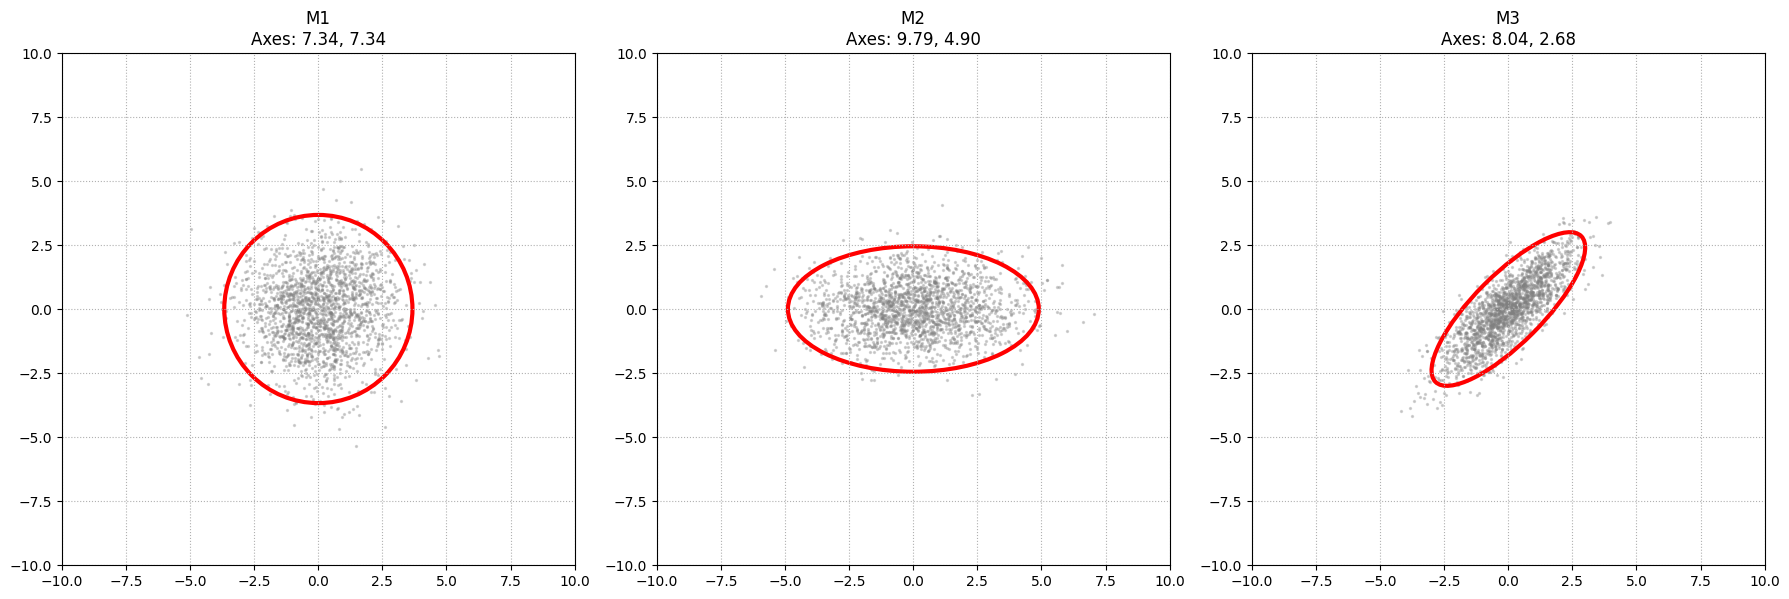

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2


def get_ellipse(cov_matrix, alpha=0.95):
    chi2_val = chi2.ppf(alpha, df=2)
    scale_factor = np.sqrt(chi2_val)
    eig_vals, eig_vecs = np.linalg.eigh(cov_matrix)

    width = 2 * scale_factor * np.sqrt(eig_vals[1])
    height = 2 * scale_factor * np.sqrt(eig_vals[0])

    largest_eigenvec = eig_vecs[:, 1]
    angle = np.degrees(np.arctan2(largest_eigenvec[1], largest_eigenvec[0]))

    return width, height, angle


N = 2000
alpha = 0.95
center = [0, 0]


sigma_1 = 1.5
S1 = (sigma_1**2) * np.identity(2)
points1 = np.random.randn(N, 2) @ np.linalg.cholesky(S1).T

sigmas_2 = [2.0, 1.0]
S2 = np.diag(np.array(sigmas_2) ** 2)
points2 = np.random.randn(N, 2) @ np.linalg.cholesky(S2).T


S3 = np.array([[1.5, 1.2], [1.2, 1.5]])
points3 = np.random.randn(N, 2) @ np.linalg.cholesky(S3).T


matrices = [S1, S2, S3]
points_list = [points1, points2, points3]
titles = ["M1", "M2", "M3"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, ax in enumerate(axes):
    S = matrices[i]
    pts = points_list[i]

    ax.scatter(pts[:, 0], pts[:, 1], s=2, alpha=0.3, color="gray")

    w, h, angle = get_ellipse(S, alpha=alpha)

    ell = Ellipse(
        xy=center,
        width=w,
        height=h,
        angle=angle,
        edgecolor="red",
        facecolor="none",
        lw=3,
    )
    ax.add_patch(ell)

    ax.set_title(f"{titles[i]}\nAxes: {w:.2f}, {h:.2f}")
    ax.set_aspect("equal")
    limit = 10
    ax.set_xlim(-limit, limit)
    ax.set_ylim(-limit, limit)
    ax.grid(True, linestyle=":")

plt.tight_layout()
plt.show()

## Implementacja

Projekt został zrealizowany w języku **Python**.

* Do symulacji i wizualizacji użyłem **Gymnasium**, konkretniej API do środowiska `BipedalWalker-v3`.
* Sieć neuronowa została zaimplementowana w **numpy**.
* CMA-ES - użyłem biblioteki `pycma`, która zawiera gotową implementację algorytmu.

### Optymalizacje
   1. Normalizacja: Wejście sieci jest skalowane, żeby wszystko mieściło się w przedziale $[-1. 1]$.
   2. Action Smoothing: Branie pod uwagi również poprzedniej akcji przy tworzeniu nowej akcji.
   3. Kara za stanie w miejscu.
   4. Populacja jest ewaluowana wielowątkowo.


## Wyniki
Model bez normalizacji i uwzględniania poprzedniej akcji miał bardzo słabą zbieżność i przez pierwsze 300 generacji nauczył się dopiero nie wywracać, natomiast reszta modeli bardzo szybko nauczyła się przesuwać do przodu. Sieć neuronowa używa funkcji $tanh$ jako f. aktywacyjnej pomiędzy warstwami. Dla wartości z $[-1, 1]$ jest praktycznie liniowa, więc czuła na zmiany. Dla większych wartości (występujących bez normalizacji), sieć się nasyca i jest mniej wrażliwa na zmiany w wejściu, co opóźnia zbieżność.

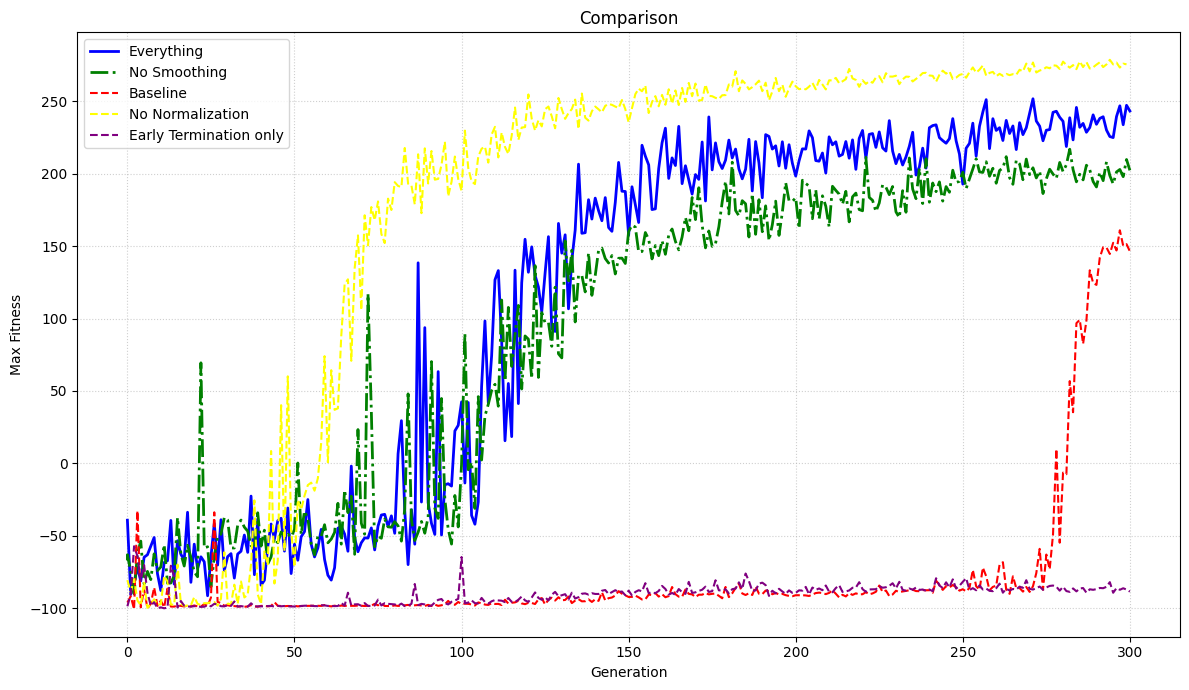

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_training_results(opt_path, no_opt_path, no_sm_path, no_norm_path, term_only_path):
    df_opt = pd.read_csv(opt_path)
    df_no_opt = pd.read_csv(no_opt_path)
    df_no_sm = pd.read_csv(no_sm_path)
    df_no_norm = pd.read_csv(no_norm_path)[:300]
    df_term_only = pd.read_csv(term_only_path)

    plt.figure(figsize=(12, 7))

    plt.plot(df_opt['generation'], df_opt['max_fitness'],
             label='Everything', color='blue', linewidth=2)

    plt.plot(df_no_sm['generation'], df_no_sm['max_fitness'],
             label='No Smoothing', color='green', linewidth=2, linestyle='-.')

    plt.plot(df_no_opt['generation'], df_no_opt['max_fitness'],
             label='Baseline', color='red', linestyle='--')

    plt.plot(df_no_norm['generation'], df_no_norm['max_fitness'],
             label='No Normalization', color='yellow', linestyle='--')

    plt.plot(df_term_only ['generation'], df_term_only ['max_fitness'],
             label='Early Termination only', color='purple', linestyle='--')

    plt.title('Comparison')
    plt.xlabel('Generation')
    plt.ylabel('Max Fitness')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()


    plt.tight_layout()
    plt.show()

opt_path = "../training_opt_log.csv"
no_opt_path = "../training_no_opt_log.csv"
no_sm_path = "../training_no_smoothing_log.csv"
no_norm_path = "../training_no_normalization_log.csv"
term_only_path = "../training_early_termination_only_log.csv"
plot_training_results(opt_path, no_opt_path, no_sm_path, no_norm_path, term_only_path)

Poniżej wyniki dla poszczególnych modeli po 300 generacjach. Model ze wszystkimi optymalizacjami chodzi najnaturalniej, model bez normalizacji/smoothingu nauczył się chodzić opierając się o kolano dla stabilności i dodatkowo wybija się z niego. Pierwszy wynik jest o tyle dobry, że możnaby go użyć jako punktu startowego w trudniejszych środowiskach. Model bez żadnych optymalizacji nie nauczył się chodzić w 300 generacji.


In [6]:
from IPython.display import HTML, display

gifs = [
    {"path": "../results/opt/result.gif", "label": "Wszytkie optymalizacjie"},
    {"path": "../results/no_early_termination/result.gif", "label": "Bez optymalizacji"},
    {"path": "../results/no_normalization/result.gif", "label": "Bez Normalizacji"},
    {"path": "../results/no_smoothing/result.gif", "label": "Bez Smoothingu"},
]

html_content = '<div style="display: flex; flex-wrap: wrap; gap: 20px; justify-content: center;">'

for item in gifs:
    html_content += f'''
    <div style="text-align: center; margin-bottom: 20px;">
        <h3 style="font-family: monospace; margin-bottom: 5px;">{item["label"]}</h3>
        <img src="{item["path"]}" style="width: 300px; border: 1px solid #ccc; border-radius: 5px;">
    </div>
    '''

html_content += '</div>'

display(HTML(html_content))